# Read and plot the original source

Same complete `moi10_all` readout and plotting options as `read_atst.ipynb`. Source ranges and condition annotations remain explicit; no ATST file is read. Matplotlib plots the source values directly.


In [1]:
from pathlib import Path
import math
import matplotlib.pyplot as plt
import pandas as pd

readout_id = "moi10_all"
rows, curves = [], []

with pd.ExcelFile(
    "read_shared_data/sources/Plate reader/Plate_reader_raw.xlsx"
) as book:
    for sheet in book.sheet_names:
        raw = pd.read_excel(
            book, sheet_name=sheet, header=None, dtype=str, keep_default_na=False
        )
        raw = raw.loc[raw.ne("").any(axis=1)]
        # Reuse curated source-column annotations, not the exported ATST layout.
        layout = pd.read_csv(
            Path("read_shared_data/layout_inputs")
            / ("layout_raw_" + sheet.replace(" ", "_").replace("-", "_") + ".tsv"),
            sep="\t",
            dtype=str,
            keep_default_na=False,
        )
        time = pd.to_numeric(raw.iloc[1:, 0]).to_numpy()
        for column, row in enumerate(layout.to_dict("records"), 1):
            rows.append(row)
            curves.append(
                pd.Series(pd.to_numeric(raw.iloc[1:, column]).to_numpy(), index=time)
            )

# Local curve IDs preserve source order; different time grids align without interpolation.
layout = pd.DataFrame(rows)
layout["curve_id"] = [f"curve_{i}" for i in range(1, len(rows) + 1)]
readings = pd.concat(curves, axis=1).sort_index()
readings.columns = layout["curve_id"]
readings = readings.rename_axis("Time").reset_index()


/var/folders/3x/jq98_hcj2sb_2d4s_z6l2sfw0000gn/T/ipykernel_60056/2276078357.py:37: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  readings = readings.rename_axis("Time").reset_index()


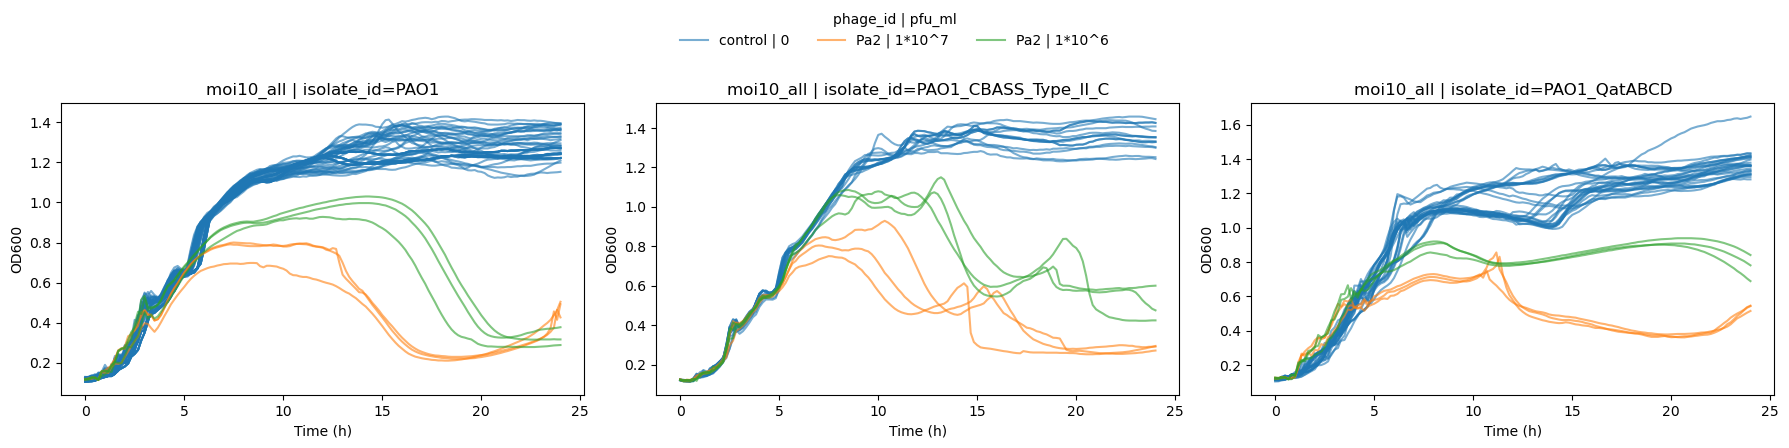

In [2]:
filtered_layout = layout[layout["phage_id"].isin(["Pa2", ""])]
panels = [(isolate, panel) for isolate, panel in filtered_layout.groupby("isolate_id", sort=False)
          if {"Pa2", ""}.issubset(set(panel["phage_id"]))]
ncols = min(3, len(panels))
nrows = math.ceil(len(panels) / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4.5 * nrows), squeeze=False)
palette = plt.rcParams["axes.prop_cycle"].by_key()["color"]
condition_colors = {}

for ax, (panel, panel_layout) in zip(axes.flat, panels):
    for condition, group in panel_layout.groupby(["phage_id", "pfu_ml"], sort=False):
        if condition == ("", ""):
            condition = ("control", "0")
        # if condition[0] != 'Pa2':
        #     continue
        if condition not in condition_colors:
            condition_colors[condition] = palette[len(condition_colors) % len(palette)]
        color = condition_colors[condition]
        label = " | ".join("control" if index == 0 and (pd.isna(value) or value == "") else str(value)
                           for index, value in enumerate(condition))
        values = readings[group["curve_id"]]
        for index, curve_id in enumerate(group["curve_id"]):
            ax.plot(
                readings["Time"],
                readings[curve_id],
                color=color,
                alpha=0.6,
                label=label if index == 0 else None,
            )
    ax.set_xlabel("Time (h)")
    ax.set_ylabel("OD600")
    panel_label = "<blank>" if panel == "" else str(panel)
    ax.set_title(f"{readout_id} | isolate_id={panel_label}")

for ax in list(axes.flat)[len(panels) :]:
    fig.delaxes(ax)

legend_entries = {}
for ax in fig.axes:
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        legend_entries.setdefault(label, handle)
ncols = 1 if max(map(len, legend_entries)) > 40 else min(4, len(legend_entries))
fig.legend(
    list(legend_entries.values()), list(legend_entries),
    title='phage_id | pfu_ml', loc="upper center", ncol=ncols, frameon=False,
)
legend_height = (0.25 * math.ceil(len(legend_entries) / ncols) + 0.4) / fig.get_figheight()
fig.tight_layout(rect=(0, 0, 1, 1 - legend_height))
plt.show()


Individual source curves are shown; the merged readout repeats control replicate IDs within some isolate/condition groups.
